# External-Polymer Prediction (final)

Predicts crystallizability (**XGB FP+pooled poly**) and melting temperature (**XGB FP+pooled RU**) for **external** polymers using the full-data deployment models, with separate classification/regression domain-of-validity flags.

These models are trained on all internal data and are for external predictions only — not for Table 1 / reported metrics.

## Setup & imports

In [1]:
# ─────────────────────────────────────────────────────────────────────────────
# 1. Project imports
# ─────────────────────────────────────────────────────────────────────────────
# %%
import sys
from pathlib import Path
sys.path.append(str(Path(PATH TO PBSG)))

import pbsg
from pbsg.polymer import polymers_from_df
from pbsg.polymer.generators import smiles_from_graphs
from pbsg.ml import to_pyg
from pbsg.ml.pyg import architecture_onehot
from pbsg.polymer.parser import parse_smiles_list
import ast

def safe_parse(val):
    try:
        if pd.isna(val): return None
    except (TypeError, ValueError): pass
    while isinstance(val, str):
        try: val = ast.literal_eval(val)
        except (ValueError, SyntaxError): break
    return val

import torch 

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

/Users/xgv7306/miniconda3/envs/pbsg/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── Model architecture constants (kept for feature builders) ──────────────────
IN_CHANNELS = 85
EDGE_DIM    = 1
META_DIM    = 13
DESC_START  = 64
DESC_END    = 82

# ══════════════════════════════════════════════════════════════════════════════
# FULL-DATA DEPLOYMENT MODELS — for EXTERNAL polymer predictions only.
# Best regressor: XGB (FP+pooled RU).  Best classifier: XGB (FP+pooled poly).
# These are trained on ALL internal data; NOT for Table 1 / reported metrics.
# ══════════════════════════════════════════════════════════════════════════════
REG_DIR = "Regressor_final_fulldata"
CLS_DIR = "Classifier_final_fulldata"

MODEL_PATHS = {
    # Regression — XGB FP+pooled RU (full data)
    "reg_xgb_ru":        f"{REG_DIR}/reg_xgb_pooled_ru_FULL.pkl",
    "xgb_ru_xscaler":    f"{REG_DIR}/reg_xgb_pooled_ru_FULL_xscaler.pkl",
    # Classification — XGB FP+pooled poly (full data)
    "cls_xgb":           f"{CLS_DIR}/cls_xgb_pooled_poly_FULL.pkl",

    "dov_cls":           f"{CLS_DIR}/dov_cls_full.pkl",
    "dov_reg":           f"{REG_DIR}/dov_reg_full.pkl",
    # Threshold — carried over (held-out-validated) for the poly classifier
    "cls_thresholds":    f"{CLS_DIR}/cls_threshold.json",
}


## Load models

In [3]:
import json
import joblib
from dov import DomainOfValidity

In [4]:
def load_models(model_paths=MODEL_PATHS, verbose=True):
    """
    Load the FULL-DATA deployment models (XGB-RU regressor, XGB-poly classifier),
    their scaler, the DoV objects, and the carried-over threshold.
    For EXTERNAL polymer predictions only.
    """
    models = {}


    # ── Classification XGB (FP+pooled poly, full data) ────────────────────────
    models["cls_xgb"] = joblib.load(model_paths["cls_xgb"])
    if verbose:
        print(f"  \u2713 Classifier XGB-poly loaded from {model_paths['cls_xgb']}")

    # ── Regression XGB (FP+pooled RU, full data) + scaler ─────────────────────
    models["reg_xgb_ru"]    = joblib.load(model_paths["reg_xgb_ru"])
    models["xgb_ru_xscaler"] = joblib.load(model_paths["xgb_ru_xscaler"])
    if verbose:
        print(f"  \u2713 Regressor XGB-RU loaded from {model_paths['reg_xgb_ru']}")

    # ── DoV (full data) ───────────────────────────────────────────────────────
    models["dov_cls"] = joblib.load(model_paths["dov_cls"])
    models["dov_reg"] = joblib.load(model_paths["dov_reg"])
    if verbose:
        print(f"  \u2713 DoV (clf, full) loaded")
        print(f"  \u2713 DoV (reg, full) loaded")

    if verbose:
        print("\nDeployment models loaded (EXTERNAL predictions only).")
    return models


# Threshold for the poly classifier (carried over from held-out run)
with open(MODEL_PATHS["cls_thresholds"]) as f:
    _thr = json.load(f)
CLS_THRESHOLD = _thr.get("xgb_fp_pooled_poly", 0.5)
print(f"Classifier threshold (xgb_poly): {CLS_THRESHOLD}")

print("Loading deployment models...")
_MODELS = load_models(verbose=True)


Classifier threshold (xgb_poly): 0.8112525939941406
Loading deployment models...
  ✓ Classifier XGB-poly loaded from Classifier_final_fulldata/cls_xgb_pooled_poly_FULL.pkl
  ✓ Regressor XGB-RU loaded from Regressor_final_fulldata/reg_xgb_pooled_ru_FULL.pkl
  ✓ DoV (clf, full) loaded
  ✓ DoV (reg, full) loaded

Deployment models loaded (EXTERNAL predictions only).


## Feature builders

In [5]:
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator
from rdkit import Chem
import numpy as np

from rdkit import Chem
from rdkit.Chem.rdFingerprintGenerator import GetMorganGenerator, FingerprintGenerator32
_gen = GetMorganGenerator(radius=2, fpSize=1024, includeChirality=True)
DESC_START, DESC_END = 64, 82


def _build_graph_and_beads(row_dict: dict):
    """
    Build PyG Data object AND return bead_polymer object.
    Returns (data, bead_polymer) or (None, None) on failure.
    """
    import random
    random.seed(42)
    np.random.seed(42)
    torch.manual_seed(42)

    df_single = pd.DataFrame([row_dict])
    df_single["beads_list"]          = df_single["repeat_units"].apply(
        parse_smiles_list)
    df_single["architecture_onehot"] = df_single.apply(
        architecture_onehot, axis=1)

    bead_polymers = polymers_from_df(df_single, total_chain_length=40)
    if not bead_polymers:
        return None, None

    bead_polymer = bead_polymers[0]
    data = to_pyg(bead_polymer, stereo=True)
    if data is None:
        return None, None

    data.x         = data.x.float()
    data.edge_attr = data.edge_attr.float()
    return data, bead_polymer


def _build_flat_ru(data, bead_polymer) -> np.ndarray:
    """
    RepFP+pooled — matches build_flat_features(graphs, bead_polymers).
    FP = mean Morgan FP over unique bead SMILES from bead_polymer.nodes.
    """
    pooled_desc = data.x.float().numpy()[:, DESC_START:DESC_END].mean(axis=0)
    meta        = data.architecture.float().numpy().flatten()
    ea          = data.edge_attr
    pooled_edge = (ea.float().numpy().mean(axis=0)
                   if ea is not None and ea.numel() > 0
                   else np.zeros(
                       ea.shape[1] if ea is not None else 1,
                       dtype=np.float32))

    # Unique bead SMILES from bead_polymer nodes
    smis   = [b.bead_id for b in bead_polymer.nodes]
    u_smis = list(set(smis))
    fps    = []
    for smi in u_smis:
        mol = Chem.MolFromSmiles(smi)
        fp  = (np.array(_gen.GetFingerprintAsNumPy(mol), dtype=np.float32)
               if mol is not None else np.zeros(1024, dtype=np.float32))
        fps.append(fp)
    fp_avg = np.mean(np.array(fps), axis=0)

    return np.concatenate([fp_avg, pooled_desc, meta, pooled_edge])


def _build_flat_poly(data, p_smiles: str) -> np.ndarray:
    """
    PolyFP+pooled — FP from full polymer SMILES (p_smiles).
    Matches build_flat_features(graphs, polymers) where mol = p_smiles.
    """
    pooled_desc = data.x.float().numpy()[:, DESC_START:DESC_END].mean(axis=0)
    meta        = data.architecture.float().numpy().flatten()
    ea          = data.edge_attr
    pooled_edge = (ea.float().numpy().mean(axis=0)
                   if ea is not None and ea.numel() > 0
                   else np.zeros(
                       ea.shape[1] if ea is not None else 1,
                       dtype=np.float32))

    mol = Chem.MolFromSmiles(str(p_smiles))
    fp  = (np.array(_gen.GetFingerprintAsNumPy(mol), dtype=np.float32)
           if mol is not None else np.zeros(1024, dtype=np.float32))

    return np.concatenate([fp, pooled_desc, meta, pooled_edge])

## Prediction functions

In [6]:
# ══════════════════════════════════════════════════════════════════════════════
# EXTERNAL-POLYMER PREDICTION  (full-data XGB models: RU regressor, Poly classifier)
# ══════════════════════════════════════════════════════════════════════════════
import pandas as pd

def predict_polymer_tm(
    repeat_units:   str,
    stereo_class:   str,
    polymer_type:   str   = "homopolymer",
    copolymer_type: str   = None,
    lengths               = None,
    Pm:             float = None,
    cls_threshold:  float = None,
    verbose:        bool  = True,
) -> dict:
    """
    Predict crystallizability (XGB-poly) and Tm (XGB-RU) for an EXTERNAL polymer,
    with separate classification / regression domain-of-validity flags.
    """
    if cls_threshold is None:
        cls_threshold = CLS_THRESHOLD

    row = {
        "repeat_units": repeat_units, "stereo_class": stereo_class,
        "polymer_type": polymer_type, "copolymer_type": copolymer_type,
        "lengths": lengths, "Pm": Pm,
    }

    data, bead_polymer = _build_graph_and_beads(row)
    if data is None:
        return {"error": f"Could not build features for: {repeat_units}"}

    result = {
        "repeat_units": repeat_units, "stereo_class": stereo_class,
        "polymer_type": polymer_type, "Pm": Pm,
    }

    # ── Build feature vectors ─────────────────────────────────────────────────
    df_single = pd.DataFrame([row])
    df_single["beads_list"]          = df_single["repeat_units"].apply(parse_smiles_list)
    df_single["architecture_onehot"] = df_single.apply(architecture_onehot, axis=1)
    poly_df = smiles_from_graphs(df_single, total_chain_length=40)
    p_smiles = poly_df["p_smiles"].iloc[0] if len(poly_df) > 0 else repeat_units

    x_ru   = _build_flat_ru(data, bead_polymer).reshape(1, -1)
    x_poly = _build_flat_poly(data, p_smiles).reshape(1, -1)

    # ── Classification — XGB poly (unscaled poly features, as trained) ────────
    xgb_prob = float(_MODELS["cls_xgb"].predict_proba(x_poly)[0, 1])
    result["has_Tm_prob"] = round(xgb_prob, 4)
    result["has_Tm_pred"] = xgb_prob >= cls_threshold
    result["cls_threshold"] = round(cls_threshold, 4)

    # ── Regression — XGB RU (scaled) ──────────────────────────────────────────
    x_ru_scaled = _MODELS["xgb_ru_xscaler"].transform(x_ru)
    tm_pred = float(_MODELS["reg_xgb_ru"].predict(x_ru_scaled)[0])
    result["Tm_pred"] = round(tm_pred, 1)

    # ── DoV — separate clf and reg ────────────────────────────────────────────
    dov_c, _, in_dom_c_full, _ = _MODELS["dov_cls"].score([repeat_units], [stereo_class])
    dov_r, _, in_dom_r_full, _ = _MODELS["dov_reg"].score([repeat_units], [stereo_class])
    dov_score_cls = float(dov_c[0]); in_domain_cls = bool(in_dom_c_full[0])
    dov_score_reg = float(dov_r[0]); in_domain_reg = bool(in_dom_r_full[0])

    bins   = [0, 0.3, 0.5, 0.7, 1.01]
    labels = ["Very low", "Low", "Moderate", "High"]
    tier = lambda s: labels[np.searchsorted(bins[1:], s, side="left")]

    result["dov_score_cls"]  = round(dov_score_cls, 4)
    result["in_domain_cls"]  = in_domain_cls
    result["confidence_cls"] = tier(dov_score_cls)
    result["dov_score_reg"]  = round(dov_score_reg, 4)
    result["in_domain_reg"]  = in_domain_reg
    result["confidence_reg"] = tier(dov_score_reg)

    # ── Notes ─────────────────────────────────────────────────────────────────
    if not result["has_Tm_pred"]:
        cls_note = (f"Predicted non-crystallizable (P={xgb_prob:.2f} < {cls_threshold:.2f}). "
                    f"DoV={dov_score_cls:.3f} ({result['confidence_cls']}).")
    elif not in_domain_cls:
        cls_note = (f"Predicted crystallizable (P={xgb_prob:.2f}) but outside classification "
                    f"domain (DoV={dov_score_cls:.3f}). Treat with caution.")
    else:
        cls_note = (f"Predicted crystallizable. P={xgb_prob:.2f}. "
                    f"DoV={dov_score_cls:.3f} ({result['confidence_cls']}).")

    if not in_domain_reg:
        reg_note = (f"Predicted Tm={tm_pred:.1f}\u00b0C but outside regression domain "
                    f"(DoV={dov_score_reg:.3f}). Treat with caution.")
    else:
        reg_note = (f"Predicted Tm={tm_pred:.1f}\u00b0C. "
                    f"DoV={dov_score_reg:.3f} ({result['confidence_reg']}).")

    result["cls_note"] = cls_note
    result["reg_note"] = reg_note

    if verbose:
        line_long  = "─" * 60
        line_short = "─" * 56
        check = "✓" if result["has_Tm_pred"] else "✗"
        print(f"\n{line_long}")
        print(f"  Polymer:  {repeat_units[:50]}")
        print(f"  Stereo:   {stereo_class}  |  Pm: {Pm}")
        print(f"  {line_short}")
        print(f"  XGB-poly P(has_Tm): {xgb_prob:.3f}  (thresh={cls_threshold:.3f})  →  {check}")
        print(f"  XGB-RU   Tm pred:   {tm_pred:.1f}°C")
        print(f"  {line_short}")
        print(f"  DoV (clf): {dov_score_cls:.3f} ({result['confidence_cls']})  in_domain={in_domain_cls}")
        print(f"  DoV (reg): {dov_score_reg:.3f} ({result['confidence_reg']})  in_domain={in_domain_reg}")
        print(f"  {line_short}")
        print(f"  CLS: {cls_note}")
        print(f"  REG: {reg_note}")
        print(f"{line_long}")

    return result


# ══════════════════════════════════════════════════════════════════════════════
# BATCH VERSION
# ══════════════════════════════════════════════════════════════════════════════
def predict_batch(df_query: pd.DataFrame, cls_threshold: float = None,
                  verbose: bool = False) -> pd.DataFrame:
    """Run external-polymer prediction over a DataFrame.
    Required cols: repeat_units, stereo_class. Optional: polymer_type,
    copolymer_type, lengths, Pm."""
    results = []
    for _, row in df_query.iterrows():
        results.append(predict_polymer_tm(
            repeat_units   = row.get("repeat_units", ""),
            stereo_class   = row.get("stereo_class", "atactic"),
            polymer_type   = row.get("polymer_type", "homopolymer"),
            copolymer_type = row.get("copolymer_type", None),
            lengths        = row.get("lengths", None),
            Pm             = row.get("Pm", None),
            cls_threshold  = cls_threshold,
            verbose        = verbose,
        ))
    results_df = pd.DataFrame(results)
    drop_cols = [c for c in results_df.columns if c in df_query.columns]
    results_df = results_df.drop(columns=drop_cols)
    return pd.concat([df_query.reset_index(drop=True), results_df], axis=1)


## Example: single prediction

In [7]:
# ── Example: single external polymer ─────────────────────────────────────────

#Canonicalize the SMILES for the repeat unit before making prediction
smi = '[*]C(C(COC(C(C)CO[*])=O)C)=O'
mol = Chem.MolFromSmiles(smi)
canonical = Chem.MolToSmiles(mol)
print(canonical)

result = predict_polymer_tm(
    repeat_units = canonical,
    stereo_class = "isotactic",
    Pm           = 1.0,
    verbose      = True,
)


*OCC(C)C(=O)OCC(C)C(*)=O

────────────────────────────────────────────────────────────
  Polymer:  *OCC(C)C(=O)OCC(C)C(*)=O
  Stereo:   isotactic  |  Pm: 1.0
  ────────────────────────────────────────────────────────
  XGB-poly P(has_Tm): 0.845  (thresh=0.811)  →  ✓
  XGB-RU   Tm pred:   128.1°C
  ────────────────────────────────────────────────────────
  DoV (clf): 0.379 (Low)  in_domain=False
  DoV (reg): 0.379 (Low)  in_domain=False
  ────────────────────────────────────────────────────────
  CLS: Predicted crystallizable (P=0.84) but outside classification domain (DoV=0.379). Treat with caution.
  REG: Predicted Tm=128.1°C but outside regression domain (DoV=0.379). Treat with caution.
────────────────────────────────────────────────────────────


In [16]:
# ── Example: single external polymer ─────────────────────────────────────────

#Canonicalize the SMILES for the repeat unit before making prediction
smi = '[*]O/C(C(C)(C)C([*])=O)=C(C)\C'
mol = Chem.MolFromSmiles(smi)
canonical = Chem.MolToSmiles(mol)
print(canonical)

result = predict_polymer_tm(
    repeat_units = canonical,
    stereo_class = "isotactic",
    Pm           = 1.0,
    verbose      = True,
)


*OC(=C(C)C)C(C)(C)C(*)=O

────────────────────────────────────────────────────────────
  Polymer:  *OC(=C(C)C)C(C)(C)C(*)=O
  Stereo:   isotactic  |  Pm: 1.0
  ────────────────────────────────────────────────────────
  XGB-poly P(has_Tm): 0.974  (thresh=0.811)  →  ✓
  XGB-RU   Tm pred:   152.1°C
  ────────────────────────────────────────────────────────
  DoV (clf): 0.367 (Low)  in_domain=False
  DoV (reg): 0.294 (Very low)  in_domain=False
  ────────────────────────────────────────────────────────
  CLS: Predicted crystallizable (P=0.97) but outside classification domain (DoV=0.367). Treat with caution.
  REG: Predicted Tm=152.1°C but outside regression domain (DoV=0.294). Treat with caution.
────────────────────────────────────────────────────────────


## Pm sweep 

In [8]:
from itertools import cycle
import matplotlib.pyplot as plt
import pandas as pd

# ── Build sweep dataframe ──────────────────────────────────────────────────
pm_values = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

POLYMER_NAMES = {
    "[*]C(Cl)C[*]":           "PVC",
    "CC([*])C(O[*])=O":       "PLA",
    "[*]C(C[*])c1ccccc1":     "PS",
    "[*]C(C)C[*]":            "PP",
    "CC(NC(C([*])C[*])=O)C":  "PNIPAM",
}

def pm_to_stereo(pm):
    if pm <= 0.1:   return "syndiotactic"
    elif pm >= 0.9: return "isotactic"
    else:           return "atactic"

rows = []
for smi in POLYMER_NAMES:
    for pm in pm_values:
        rows.append({
            "repeat_units":   smi,
            "Pm":             pm,
            "stereo_class":   pm_to_stereo(pm),
            "polymer_type":   "homopolymer",
            "copolymer_type": None,
            "lengths":        None,
        })

df_pm  = pd.DataFrame(rows)
#df_out = predict_batch(df_pm)

In [9]:
df_out = predict_batch(df_pm, verbose=False)
df_out

,repeat_units,Pm,stereo_class,polymer_type,copolymer_type,lengths,has_Tm_prob,has_Tm_pred,cls_threshold,Tm_pred,dov_score_cls,in_domain_cls,confidence_cls,dov_score_reg,in_domain_reg,confidence_reg,cls_note,reg_note
0,[*]C(Cl)C[*],0.0,syndiotactic,homopolymer,None,None,0.5760,False,0.8113,180.3,0.5429,False,Moderate,0.4286,False,Low,Predicted non-crystallizable (P=0.58 < 0.81). ...,Predicted Tm=180.3°C but outside regression do...
1,[*]C(Cl)C[*],0.1,syndiotactic,homopolymer,None,None,0.1652,False,0.8113,164.7,0.5429,False,Moderate,0.4286,False,Low,Predicted non-crystallizable (P=0.17 < 0.81). ...,Predicted Tm=164.7°C but outside regression do...
2,[*]C(Cl)C[*],0.2,atactic,homopolymer,None,None,0.0617,False,0.8113,164.3,0.5429,False,Moderate,0.4286,False,Low,Predicted non-crystallizable (P=0.06 < 0.81). ...,Predicted Tm=164.3°C but outside regression do...
3,[*]C(Cl)C[*],0.3,atactic,homopolymer,None,None,0.0166,False,0.8113,159.0,0.5429,False,Moderate,0.4286,False,Low,Predicted non-crystallizable (P=0.02 < 0.81). ...,Predicted Tm=159.0°C but outside regression do...
4,[*]C(Cl)C[*],0.4,atactic,homopolymer,None,None,0.0136,False,0.8113,155.5,0.5429,False,Moderate,0.4286,False,Low,Predicted non-crystallizable (P=0.01 < 0.81). ...,Predicted Tm=155.5°C but outside regression do...
5,[*]C(Cl)C[*],0.5,atactic,homopolymer,None,None,0.0082,False,0.8113,155.5,0.5429,False,Moderate,0.4286,False,Low,Predicted non-crystallizable (P=0.01 < 0.81). ...,Predicted Tm=155.5°C but outside regression do...
6,[*]C(Cl)C[*],0.6,atactic,homopolymer,None,None,0.0163,False,0.8113,163.4,0.5429,False,Moderate,0.4286,False,Low,Predicted non-crystallizable (P=0.02 < 0.81). ...,Predicted Tm=163.4°C but outside regression do...
7,[*]C(Cl)C[*],0.7,atactic,homopolymer,None,None,0.0384,False,0.8113,163.4,0.5429,False,Moderate,0.4286,False,Low,Predicted non-crystallizable (P=0.04 < 0.81). ...,Predicted Tm=163.4°C but outside regression do...
8,[*]C(Cl)C[*],0.8,atactic,homopolymer,None,None,0.3073,False,0.8113,166.0,0.5429,False,Moderate,0.4286,False,Low,Predicted non-crystallizable (P=0.31 < 0.81). ...,Predicted Tm=166.0°C but outside regression do...
9,[*]C(Cl)C[*],0.9,isotactic,homopolymer,None,None,0.9737,True,0.8113,168.9,0.5429,False,Moderate,0.4286,False,Low,Predicted crystallizable (P=0.97) but outside ...,Predicted Tm=168.9°C but outside regression do...


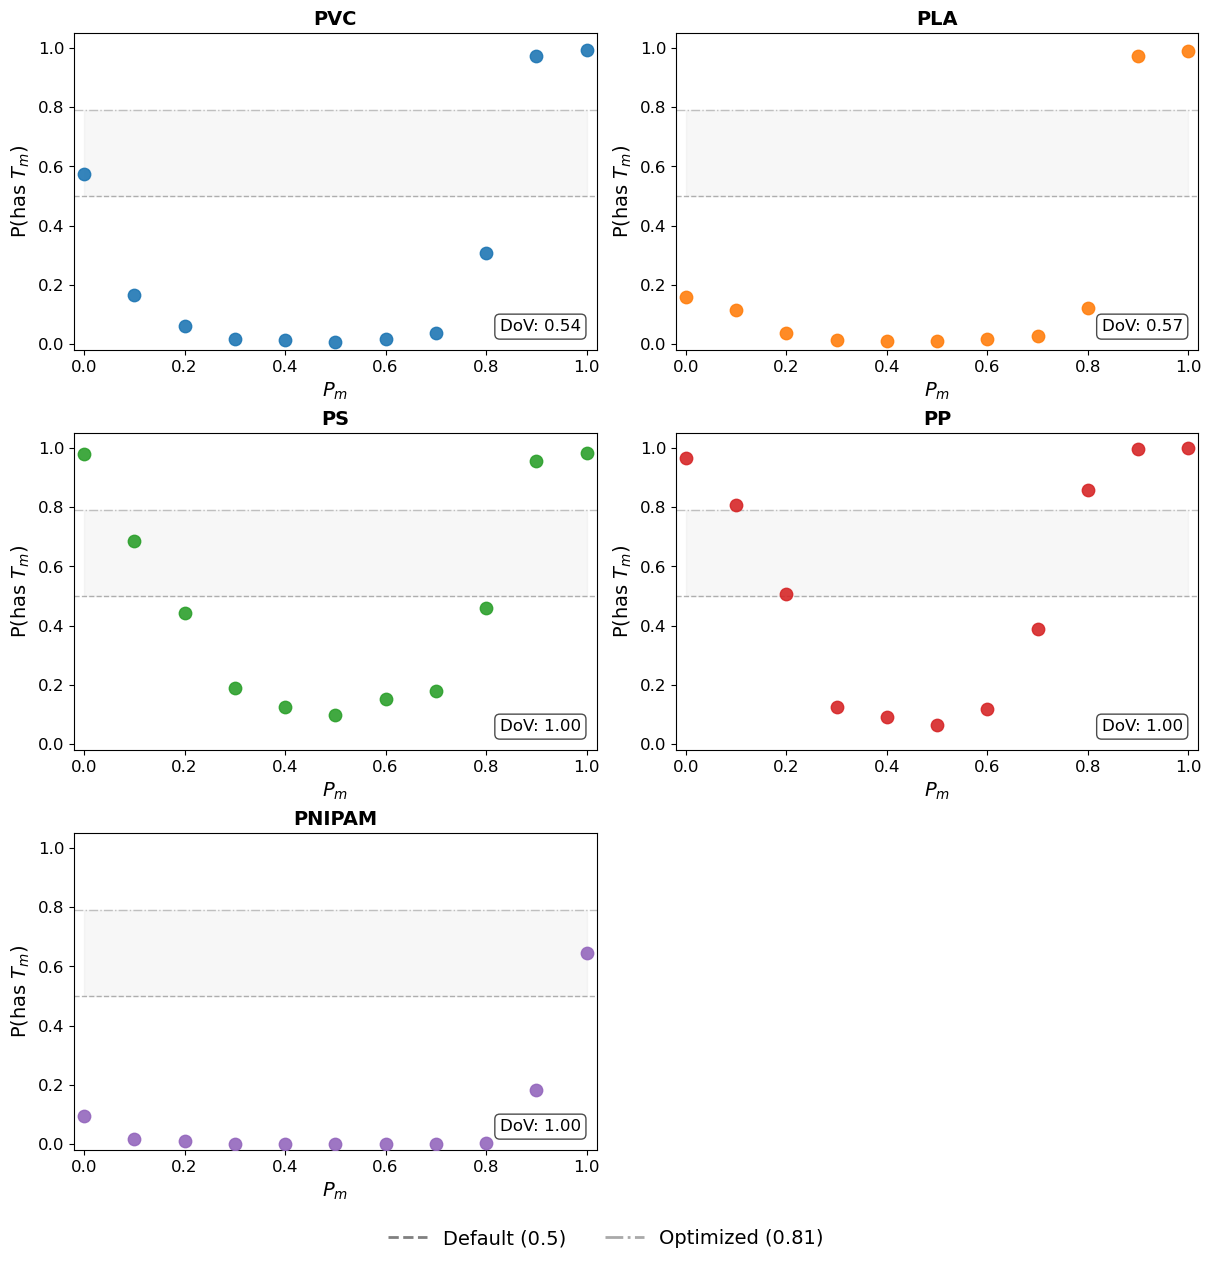

In [10]:
from math import ceil

COLORS = plt.cm.tab10.colors


polymer_colors = {}  
for (smi, name), color in zip(POLYMER_NAMES.items(), COLORS):
    polymer_colors[name] = color  

n_polymers = len(POLYMER_NAMES)
ncols = 2
nrows = ceil(n_polymers / ncols)

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(6 * ncols, 4* nrows),
                         constrained_layout=True)
axes_flat = axes.flatten()

for ax, (smi, name) in zip(axes_flat, POLYMER_NAMES.items()):
    color = polymer_colors[name]
    sub   = df_out[df_out["repeat_units"] == smi].sort_values("Pm")

    # ── Scatter only (no lines) ───────────────────────────────────────────
    ax.scatter(sub["Pm"], sub["has_Tm_prob"],
               color=color, s=80, alpha=0.9, zorder=3)

    # ── Reference lines ───────────────────────────────────────────────────
    ax.axhline(0.5,   color="grey",     ls="--", lw=1,   alpha=0.6)
    ax.axhline(0.790, color="darkgrey", ls="-.", lw=1,   alpha=0.7)
    ax.fill_between([0, 1], 0.5, 0.790, color="grey", alpha=0.06)

    # ── DoV score annotation ──────────────────────────────────────────────
    dov = df_out[df_out["repeat_units"] == smi]["dov_score_cls"].iloc[0]
    dov_thresh = _MODELS["dov_cls"].threshold_
    dov_color  = "black" if dov >= dov_thresh else "crimson"
    ax.text(0.97, 0.05, f"DoV: {dov:.2f}",
            transform=ax.transAxes, ha="right", va="bottom",
            fontsize=12, color="black",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.7))

    ax.set_title(name, fontsize=14, fontweight="bold", color="black")
    ax.set_xlabel("$P_m$", fontsize=14)
    ax.set_ylabel("P(has $T_m$)", fontsize=14)
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.05)
    ax.tick_params(axis="both", labelsize=12)
    #ax.spines[["top", "right"]].set_visible(False)

# ── Hide any unused subplots ──────────────────────────────────────────────────
for ax in axes_flat[n_polymers:]:
    ax.set_visible(False)

# ── Shared legend ─────────────────────────────────────────────────────────────
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color="grey",     ls="--", lw=2, label="Default (0.5)"),
    Line2D([0], [0], color="darkgrey", ls="-.", lw=2, label="Optimized (0.81)"),
]
fig.legend(handles=legend_elements, fontsize=14, frameon=False,
           loc="lower center", ncol=2,
           bbox_to_anchor=(0.5, -0.05))

plt.savefig("pm_sweep_cls_perpoly.pdf", dpi=300, bbox_inches="tight")
plt.show()

## Batch prediction for Yuan et al.

In [11]:
import pandas as pd

data = [
    {
        "repeat_units": "[*]C(C(C)C[*])=O.O=C(O[*])C(C)C[*].[*]C(OC(C)[*])=O",
        "Pm": None,
        "stereo_class": None,
        "polymer_type": "copolymer",
        "copolymer_type": "random",
        "lengths": [0.571, 0.093, 0.336],
        "Tm": None,
        "has_Tm": None,
        "beads_list": ["[*]C(C(C)C[*])=O", "O=C(O[*])C(C)C[*]", "[*]C(OC(C)[*])=O"],
        "architecture_onehot": [0.0, 0.0, 1.0, 0.0],
    },
    {
        "repeat_units": "[*]C(C(C)C[*])=O.O=C(O[*])C(C)C[*].[*]C(OC(C)[*])=O",
        "Pm": None,
        "stereo_class": "atactic",
        "polymer_type": "copolymer",
        "copolymer_type": "random",
        "lengths": [0.66, 0.093, 0.247],
        "Tm": None,
        "has_Tm": None,
        "beads_list": ["[*]C(C(C)C[*])=O", "O=C(O[*])C(C)C[*]", "[*]C(OC(C)[*])=O"],
        "architecture_onehot": [0.0, 0.0, 1.0, 0.0],
    },
    {
        "repeat_units": "[*]C(C(C)C[*])=O",
        "Pm": 1.0,
        "stereo_class": "isotactic",
        "polymer_type": "homopolymer",
        "copolymer_type": None,
        "lengths": None,
        "Tm": None,
        "has_Tm": None,
        "beads_list": ["[*]C(C(C)C[*])=O"],
        "architecture_onehot": [0.0, 0.0, 0.0, 1.0],
    },
    {
        "repeat_units": "[*]C(C(C)C[*])=O",
        "Pm": 0.5,
        "stereo_class": "atactic",
        "polymer_type": "homopolymer",
        "copolymer_type": None,
        "lengths": None,
        "Tm": None,
        "has_Tm": None,
        "beads_list": ["[*]C(C(C)C[*])=O"],
        "architecture_onehot": [0.0, 0.0, 0.0, 1.0],
    },

]

df = pd.DataFrame(data)
print(df.to_string())

                                          repeat_units   Pm stereo_class polymer_type copolymer_type                lengths    Tm has_Tm                                               beads_list   architecture_onehot
0  [*]C(C(C)C[*])=O.O=C(O[*])C(C)C[*].[*]C(OC(C)[*])=O  NaN         None    copolymer         random  [0.571, 0.093, 0.336]  None   None  [[*]C(C(C)C[*])=O, O=C(O[*])C(C)C[*], [*]C(OC(C)[*])=O]  [0.0, 0.0, 1.0, 0.0]
1  [*]C(C(C)C[*])=O.O=C(O[*])C(C)C[*].[*]C(OC(C)[*])=O  NaN      atactic    copolymer         random   [0.66, 0.093, 0.247]  None   None  [[*]C(C(C)C[*])=O, O=C(O[*])C(C)C[*], [*]C(OC(C)[*])=O]  [0.0, 0.0, 1.0, 0.0]
2                                     [*]C(C(C)C[*])=O  1.0    isotactic  homopolymer           None                   None  None   None                                       [[*]C(C(C)C[*])=O]  [0.0, 0.0, 0.0, 1.0]
3                                     [*]C(C(C)C[*])=O  0.5      atactic  homopolymer           None                   None  None   None

In [12]:
df_out2 = predict_batch(df, verbose=True)
df_out2


────────────────────────────────────────────────────────────
  Polymer:  [*]C(C(C)C[*])=O.O=C(O[*])C(C)C[*].[*]C(OC(C)[*])=
  Stereo:   None  |  Pm: nan
  ────────────────────────────────────────────────────────
  XGB-poly P(has_Tm): 0.414  (thresh=0.811)  →  ✗
  XGB-RU   Tm pred:   135.3°C
  ────────────────────────────────────────────────────────
  DoV (clf): 0.356 (Low)  in_domain=False
  DoV (reg): 0.343 (Low)  in_domain=False
  ────────────────────────────────────────────────────────
  CLS: Predicted non-crystallizable (P=0.41 < 0.81). DoV=0.356 (Low).
  REG: Predicted Tm=135.3°C but outside regression domain (DoV=0.343). Treat with caution.
────────────────────────────────────────────────────────────

────────────────────────────────────────────────────────────
  Polymer:  [*]C(C(C)C[*])=O.O=C(O[*])C(C)C[*].[*]C(OC(C)[*])=
  Stereo:   atactic  |  Pm: nan
  ────────────────────────────────────────────────────────
  XGB-poly P(has_Tm): 0.296  (thresh=0.811)  →  ✗
  XGB-RU   Tm pre

,repeat_units,Pm,stereo_class,polymer_type,copolymer_type,lengths,Tm,has_Tm,beads_list,architecture_onehot,...,cls_threshold,Tm_pred,dov_score_cls,in_domain_cls,confidence_cls,dov_score_reg,in_domain_reg,confidence_reg,cls_note,reg_note
0,[*]C(C(C)C[*])=O.O=C(O[*])C(C)C[*].[*]C(OC(C)[...,NaN,None,copolymer,random,"[0.571, 0.093, 0.336]",None,None,"[[*]C(C(C)C[*])=O, O=C(O[*])C(C)C[*], [*]C(OC(...","[0.0, 0.0, 1.0, 0.0]",...,0.8113,135.3,0.3559,False,Low,0.3429,False,Low,Predicted non-crystallizable (P=0.41 < 0.81). ...,Predicted Tm=135.3°C but outside regression do...
1,[*]C(C(C)C[*])=O.O=C(O[*])C(C)C[*].[*]C(OC(C)[...,NaN,atactic,copolymer,random,"[0.66, 0.093, 0.247]",None,None,"[[*]C(C(C)C[*])=O, O=C(O[*])C(C)C[*], [*]C(OC(...","[0.0, 0.0, 1.0, 0.0]",...,0.8113,119.4,0.3559,False,Low,0.3429,False,Low,Predicted non-crystallizable (P=0.30 < 0.81). ...,Predicted Tm=119.4°C but outside regression do...
2,[*]C(C(C)C[*])=O,1.0,isotactic,homopolymer,None,None,None,None,[[*]C(C(C)C[*])=O],"[0.0, 0.0, 0.0, 1.0]",...,0.8113,130.8,0.4091,False,Low,0.4091,False,Low,Predicted crystallizable (P=0.97) but outside ...,Predicted Tm=130.8°C but outside regression do...
3,[*]C(C(C)C[*])=O,0.5,atactic,homopolymer,None,None,None,None,[[*]C(C(C)C[*])=O],"[0.0, 0.0, 0.0, 1.0]",...,0.8113,100.4,0.4091,False,Low,0.4091,False,Low,Predicted non-crystallizable (P=0.01 < 0.81). ...,Predicted Tm=100.4°C but outside regression do...
